# Comparación de Clasificadores — Especies de Flores

**MAI 540 — Machine Learning | Módulo 3**

Un vivero quiere automatizar la clasificación de especies de flores a partir de las medidas de sus pétalos y sépalos, para no depender de que un botánico revise cada muestra a mano. Tu trabajo es entrenar los tres clasificadores vistos en clase — regresión logística, árbol de decisión y Naive Bayes — sobre el mismo conjunto de datos, compararlos con evidencia, y recomendar cuál usarías.

Dataset: *Iris* (incluido en `scikit-learn`), 150 muestras, 3 especies.

No hay ningún defecto escondido aquí — el notebook funciona de principio a fin. Lo que falta es que **tú entrenes los tres modelos**; el resto (evaluación y gráficas) ya está listo para que compares de forma justa.

## Cómo trabajar con Claude Code en este ejercicio

Esta tarea no es de depuración como la 3.1 — aquí no hay nada que arreglar. El riesgo distinto es que le pidas a Claude Code "entrena los tres modelos y dime cuál es mejor" y te entregue una respuesta sin que tú entiendas por qué.

1. **Entrena tú mismo, con ayuda para dudas puntuales.** Si no recuerdas la sintaxis de `DecisionTreeClassifier` o `GaussianNB`, pregunta eso específicamente — no pidas que te resuelva la celda completa.
2. **Antes de aceptar una conclusión, pide que te explique el porqué.** Si Claude Code te dice "usa regresión logística," pregúntale qué evidencia lo respalda — accuracy promedio, estabilidad entre particiones, o algo más.
3. **Verifica que los tres se evaluaron igual.** Los tres deben pasar por la misma función `evaluar_con_cv` y las mismas variables `X`, `y` — si alguno se evaluó distinto, la comparación no es justa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42

## 1. Carga de datos

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['especie'] = df['target'].map(dict(enumerate(iris.target_names)))

X = iris.data.values
y = iris.target.values

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploración inicial

Una matriz de dispersión: cada panel compara dos variables, coloreado por especie.

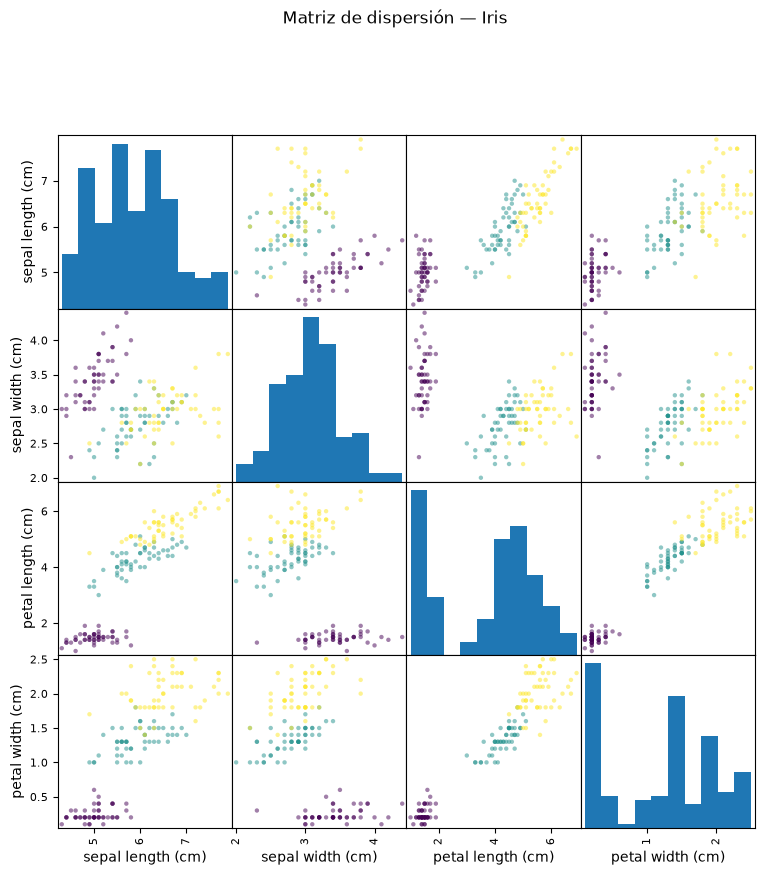

In [3]:
pd.plotting.scatter_matrix(iris.data, c=y, figsize=(9, 9), cmap='viridis', s=40)
plt.suptitle('Matriz de dispersión — Iris', y=1.02)
plt.show()

## 3. Entrena tú los tres clasificadores

Completa las tres funciones. Cada una debe entrenar el modelo indicado sobre `X` y `y`, y devolver el modelo ya entrenado (`.fit()` aplicado).

In [4]:
def entrenar_regresion_logistica(X, y):
    """Entrena una regresión logística sobre el dataset completo."""
    modelo = LogisticRegression(max_iter=5000)
    modelo.fit(X, y)
    return modelo

In [5]:
def entrenar_arbol_decision(X, y):
    """Entrena un árbol de decisión con profundidad máxima 3 (para que siga siendo interpretable)."""
    modelo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    modelo.fit(X, y)
    return modelo

In [6]:
def entrenar_naive_bayes(X, y):
    """Entrena un clasificador Naive Bayes gaussiano."""
    modelo = GaussianNB()
    modelo.fit(X, y)
    return modelo

## 4. Evaluación con validación cruzada

Un solo split de entrenamiento/prueba deja muy pocos casos para medir el accuracy con confianza (Iris solo tiene 150 muestras). Por eso comparamos con validación cruzada de 10 particiones: cada modelo se entrena y evalúa 10 veces sobre subconjuntos distintos, y miramos tanto el promedio como qué tanto varía entre particiones.

In [7]:
def evaluar_con_cv(modelo, X, y, nombre):
    """Evalúa un modelo con validación cruzada de 10 particiones y reporta media y desviación estándar."""
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(modelo, X, y, cv=cv)
    print(f"{nombre}: media={scores.mean():.4f}  desviación estándar={scores.std():.4f}  "
          f"mínimo={scores.min():.3f}  máximo={scores.max():.3f}")
    return scores

In [8]:
modelo_logreg = entrenar_regresion_logistica(X, y)
modelo_arbol = entrenar_arbol_decision(X, y)
modelo_nb = entrenar_naive_bayes(X, y)

scores_logreg = evaluar_con_cv(LogisticRegression(max_iter=5000), X, y, "Regresión logística")
scores_arbol = evaluar_con_cv(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X, y, "Árbol de decisión")
scores_nb = evaluar_con_cv(GaussianNB(), X, y, "Naive Bayes")

Regresión logística: media=0.9667  desviación estándar=0.0333  mínimo=0.933  máximo=1.000
Árbol de decisión: media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Naive Bayes: media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000


### 4.1 Dos clasificadores más: KNN y Random Forest (Tarea 4.1, punto 1)

Se agregan **K vecinos más cercanos (KNN)** y **Random Forest**, evaluados con **la misma función `evaluar_con_cv`** (10 particiones estratificadas, `random_state=RANDOM_STATE`) y **los mismos `X`, `y`** que los otros tres modelos, de modo que las cinco cifras sean comparables.

**KNN — escalado dentro del flujo de entrenamiento.** KNN mide distancias, así que la escala de cada variable influye en quién es "vecino". El `StandardScaler` va **dentro de un `Pipeline`**: en cada partición de la validación cruzada, el escalador se ajusta solo con los datos de entrenamiento de esa partición y luego se aplica a la de validación. Si se escalara `X` completo antes de dividir, la media y la desviación estándar incluirían los datos de validación (fuga de información).

**KNN — k elegido por validación, no por intuición.** El `Pipeline` se envuelve en un `GridSearchCV` que prueba k = 1…30 con una validación cruzada **interna** de 5 particiones. Como ese `GridSearchCV` es el modelo que recibe `evaluar_con_cv`, la elección de k se repite dentro de cada una de las 10 particiones externas usando solo sus datos de entrenamiento (**validación cruzada anidada**): la partición externa de validación nunca participa en la elección de k, así que el accuracy reportado no está inflado por haber elegido k mirando esos mismos datos.

**Random Forest** no necesita escalado (sus divisiones son por umbral de cada variable). Se usa la configuración por defecto (100 árboles) con `random_state=RANDOM_STATE` para que sea reproducible.

k elegido por CV interna (5 particiones) sobre todos los datos: k=5 (accuracy CV interna = 0.9733)


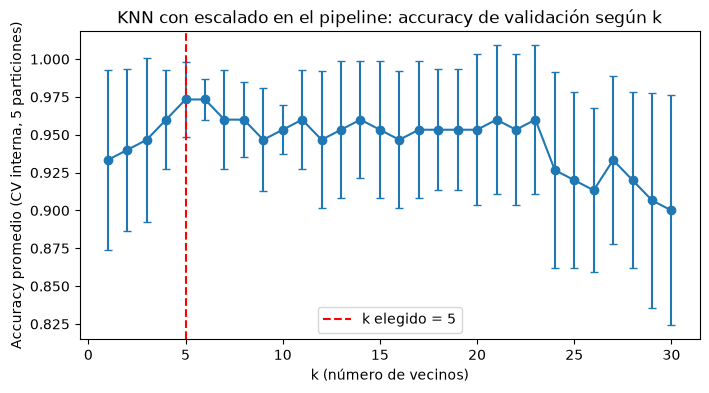

KNN (escalado en pipeline, k por CV anidada): media=0.9600  desviación estándar=0.0533  mínimo=0.867  máximo=1.000


Random Forest: media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000


k elegido en cada partición externa: [22, 11, 8, 8, 6, 3, 7, 4, 15, 12]


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

VALORES_K = list(range(1, 31))


def construir_knn_con_seleccion_de_k():
    # Pipeline (escalador + KNN) dentro de un GridSearchCV que elige k con CV interna de 5 particiones.
    flujo = Pipeline([
        ('escalador', StandardScaler()),
        ('knn', KNeighborsClassifier()),
    ])
    cv_interna = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return GridSearchCV(flujo, {'knn__n_neighbors': VALORES_K}, cv=cv_interna, scoring='accuracy')


def entrenar_knn(X, y):
    # Entrena KNN (escalado dentro del pipeline) eligiendo k por validación cruzada sobre X, y.
    modelo = construir_knn_con_seleccion_de_k()
    modelo.fit(X, y)
    return modelo


def entrenar_random_forest(X, y):
    # Entrena un Random Forest (100 árboles, semilla fija).
    modelo = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    modelo.fit(X, y)
    return modelo


# --- Modelos finales, entrenados sobre todos los datos (igual que en la sección 3) ---
modelo_knn = entrenar_knn(X, y)
modelo_rf = entrenar_random_forest(X, y)
k_elegido = modelo_knn.best_params_['knn__n_neighbors']
print(f"k elegido por CV interna (5 particiones) sobre todos los datos: k={k_elegido} "
      f"(accuracy CV interna = {modelo_knn.best_score_:.4f})")

# Curva de validación de k: evidencia de cómo se eligió k (no por intuición)
curva = modelo_knn.cv_results_
plt.figure(figsize=(8, 4))
plt.errorbar(VALORES_K, curva['mean_test_score'], yerr=curva['std_test_score'], marker='o', capsize=3)
plt.axvline(k_elegido, color='red', linestyle='--', label=f'k elegido = {k_elegido}')
plt.xlabel('k (número de vecinos)')
plt.ylabel('Accuracy promedio (CV interna, 5 particiones)')
plt.title('KNN con escalado en el pipeline: accuracy de validación según k')
plt.legend()
plt.show()

# --- Evaluación con la MISMA función y los MISMOS datos que los otros tres modelos ---
# Para KNN se pasa el GridSearchCV sin entrenar: cross_val_score lo clona y lo ajusta en cada
# partición externa, así que escalado y elección de k ocurren solo con el entrenamiento de esa partición.
scores_knn = evaluar_con_cv(construir_knn_con_seleccion_de_k(), X, y, "KNN (escalado en pipeline, k por CV anidada)")
scores_rf = evaluar_con_cv(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE), X, y, "Random Forest")

# Transparencia: qué k eligió la CV interna dentro de cada una de las 10 particiones externas
cv_externa = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
k_por_particion = []
for idx_train, _ in cv_externa.split(X, y):
    gs = construir_knn_con_seleccion_de_k().fit(X[idx_train], y[idx_train])
    k_por_particion.append(gs.best_params_['knn__n_neighbors'])
print(f"k elegido en cada partición externa: {k_por_particion}")

## 5. Visualización de fronteras de decisión

Para ver *cómo* decide cada modelo, no solo *qué tan bien*, entrenamos los tres sobre únicamente dos variables (longitud y ancho del pétalo) y graficamos la región que cada uno asigna a cada especie.

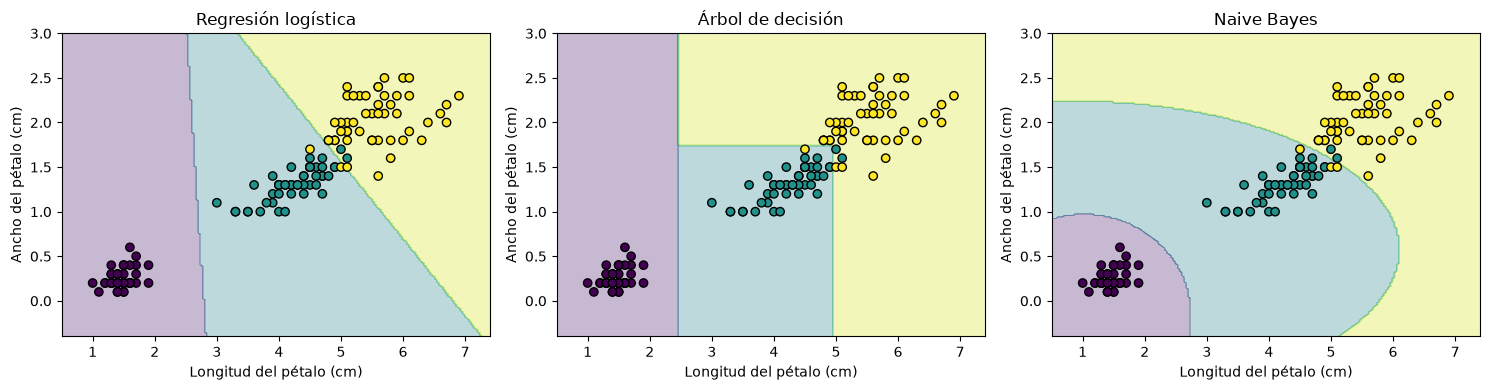

In [10]:
def graficar_frontera(modelo, X_2d, y, titulo, ax):
    """Entrena el modelo sobre dos variables y grafica su frontera de decisión."""
    modelo.fit(X_2d, y)
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor='k', cmap='viridis')
    ax.set_title(titulo)
    ax.set_xlabel('Longitud del pétalo (cm)')
    ax.set_ylabel('Ancho del pétalo (cm)')


X_2d = iris.data[['petal length (cm)', 'petal width (cm)']].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d, y, 'Regresión logística', axes[0])
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d, y, 'Árbol de decisión', axes[1])
graficar_frontera(GaussianNB(), X_2d, y, 'Naive Bayes', axes[2])
plt.tight_layout()
plt.show()

## 6. Explora la profundidad del árbol

En la sección 3 entrenaste el árbol con `max_depth=3` porque así te lo pedí. Ahora averigua tú si esa profundidad era la correcta.

Entrena el árbol con `max_depth` en 2, 3, 5 y sin límite (`None`). Para cada uno, calcula:
- el accuracy sobre el **mismo conjunto de entrenamiento completo** (`X`, `y`) — esto mide qué tanto "memorizó";
- el accuracy promedio de **validación cruzada** de 10 particiones (usa `evaluar_con_cv`, que ya tienes) — esto mide qué tan bien generaliza.

Grafica ambos accuracy (eje Y) contra la profundidad (eje X), en la misma figura, con una línea para cada uno.

Árbol (max_depth=2): media=0.9200  desviación estándar=0.0653  mínimo=0.800  máximo=1.000
Árbol (max_depth=3): media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Árbol (max_depth=5): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000
Árbol (max_depth=None): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000


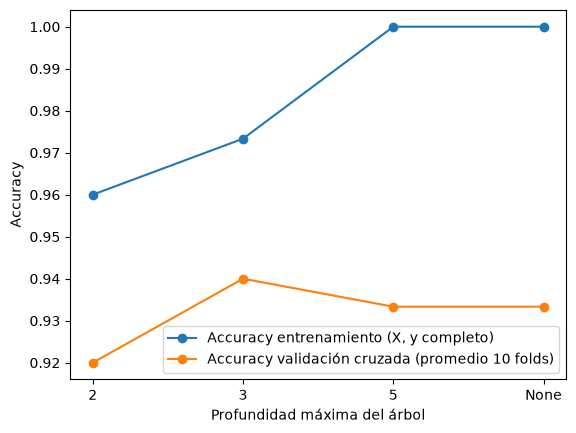

In [11]:
profundidades = [2, 3, 5, None]
accuracy_entrenamiento = []
accuracy_cv = []

for profundidad in profundidades:
    arbol = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    arbol.fit(X, y)
    accuracy_entrenamiento.append(arbol.score(X, y))

    arbol_cv = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    scores = evaluar_con_cv(arbol_cv, X, y, f"Árbol (max_depth={profundidad})")
    accuracy_cv.append(scores.mean())

etiquetas = [str(p) for p in profundidades]
plt.plot(etiquetas, accuracy_entrenamiento, marker='o', label='Accuracy entrenamiento (X, y completo)')
plt.plot(etiquetas, accuracy_cv, marker='o', label='Accuracy validación cruzada (promedio 10 folds)')
plt.xlabel('Profundidad máxima del árbol')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

¿En qué profundidad empiezan a separarse las dos líneas? Esa separación es la señal de sobreajuste — el árbol sigue mejorando en el conjunto que ya vio, pero deja de mejorar (o empeora) en datos que no vio. Anota en tu informe cuál profundidad elegirías y por qué, con la gráfica como evidencia.

## 7. Justifica las variables de la gráfica de frontera

La sección 5 usó longitud y ancho del pétalo porque yo las elegí. Repite esa misma visualización usando **otro par de variables** (por ejemplo, longitud y ancho del sépalo), y compara.

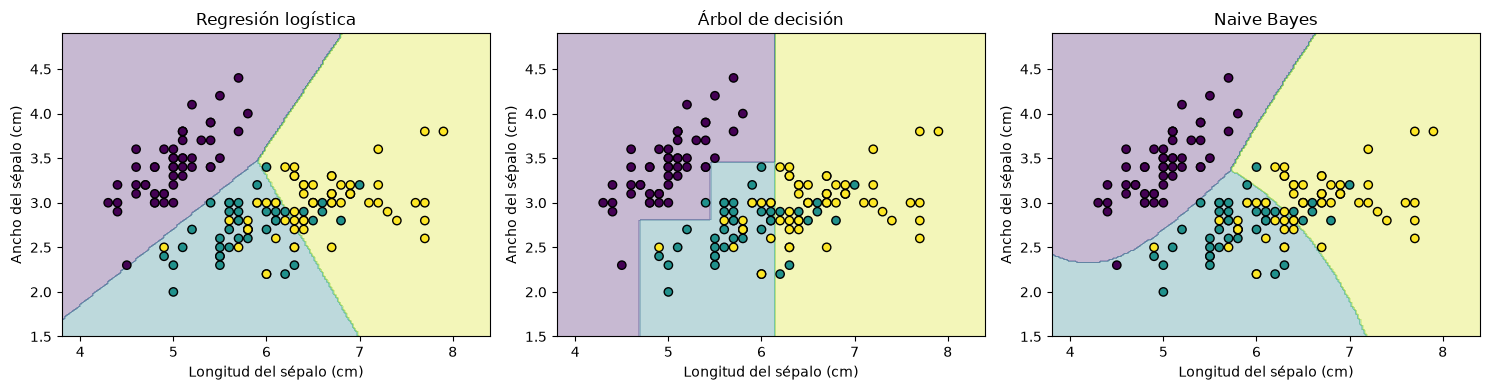

In [12]:
X_2d_alternativo = iris.data[["sepal length (cm)", "sepal width (cm)"]].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d_alternativo, y, 'Regresión logística', axes[0])
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d_alternativo, y, 'Árbol de decisión', axes[1])
graficar_frontera(GaussianNB(), X_2d_alternativo, y, 'Naive Bayes', axes[2])
for ax in axes:
    ax.set_xlabel('Longitud del sépalo (cm)')
    ax.set_ylabel('Ancho del sépalo (cm)')
plt.tight_layout()
plt.show()

In [13]:
# Evidencia cuantitativa (no solo visual) de qué par separa mejor:
# accuracy de validación cruzada de cada modelo usando SOLO esas dos variables.
print("--- Pétalo (longitud, ancho) ---")
for modelo, nombre in [(LogisticRegression(max_iter=5000), "Regresión logística"),
                        (DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), "Árbol de decisión"),
                        (GaussianNB(), "Naive Bayes")]:
    evaluar_con_cv(modelo, X_2d, y, nombre)

print("\n--- Sépalo (longitud, ancho) ---")
for modelo, nombre in [(LogisticRegression(max_iter=5000), "Regresión logística"),
                        (DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), "Árbol de decisión"),
                        (GaussianNB(), "Naive Bayes")]:
    evaluar_con_cv(modelo, X_2d_alternativo, y, nombre)

--- Pétalo (longitud, ancho) ---
Regresión logística: media=0.9600  desviación estándar=0.0442  mínimo=0.867  máximo=1.000
Árbol de decisión: media=0.9467  desviación estándar=0.0499  mínimo=0.867  máximo=1.000
Naive Bayes: media=0.9600  desviación estándar=0.0442  mínimo=0.867  máximo=1.000

--- Sépalo (longitud, ancho) ---


Regresión logística: media=0.8000  desviación estándar=0.0989  mínimo=0.600  máximo=1.000
Árbol de decisión: media=0.7467  desviación estándar=0.0581  mínimo=0.667  máximo=0.800
Naive Bayes: media=0.7867  desviación estándar=0.1222  mínimo=0.600  máximo=1.000


¿Qué par de variables separa mejor las tres especies a simple vista? En tu informe, justifica tu respuesta señalando qué observas en las gráficas (qué tanto se traslapan los colores), no solo cuál te parece más bonita.

## 8. Tabla comparativa (cinco clasificadores)

Los cinco modelos evaluados con la misma `evaluar_con_cv` (10 particiones estratificadas, `random_state=42`) sobre las 4 variables. Ordenada por accuracy promedio.

In [14]:
tabla = pd.DataFrame({
    'Clasificador': ['Regresión logística', 'Árbol de decisión', 'Naive Bayes',
                     'KNN (escalado + k por CV)', 'Random Forest'],
    'Accuracy promedio': [scores_logreg.mean(), scores_arbol.mean(), scores_nb.mean(),
                          scores_knn.mean(), scores_rf.mean()],
    'Desviación estándar': [scores_logreg.std(), scores_arbol.std(), scores_nb.std(),
                            scores_knn.std(), scores_rf.std()],
    'Mínimo': [s.min() for s in (scores_logreg, scores_arbol, scores_nb, scores_knn, scores_rf)],
    'Máximo': [s.max() for s in (scores_logreg, scores_arbol, scores_nb, scores_knn, scores_rf)],
})
tabla.sort_values('Accuracy promedio', ascending=False).reset_index(drop=True)

,Clasificador,Accuracy promedio,Desviación estándar,Mínimo,Máximo
0,Regresión logística,0.966667,0.033333,0.933333,1.0
1,KNN (escalado + k por CV),0.960000,0.053333,0.866667,1.0
2,Naive Bayes,0.953333,0.052068,0.866667,1.0
3,Random Forest,0.953333,0.052068,0.866667,1.0
4,Árbol de decisión,0.940000,0.055377,0.866667,1.0


**Lectura de la tabla con cinco clasificadores (10-fold CV, `RANDOM_STATE=42`):**

- **Regresión logística sigue primera** en accuracy promedio (0.9667) y es la más estable (desviación estándar 0.0333, mínimo 0.933); es la única que no baja de 0.933 en ninguna partición.
- **KNN** queda segundo (0.9600 ± 0.0533). Esa cifra viene de validación cruzada anidada, así que no está inflada por la elección de k. Con todos los datos, la CV interna elige **k = 5** (0.9733 en la CV interna, una cifra optimista porque es la misma que sirvió para elegir k). Pero el k elegido **cambia mucho entre particiones externas** (de 3 a 22): la curva de validación es casi plana en un rango amplio de k, así que en Iris el valor exacto de k importa poco, y su variabilidad no debe leerse como un k "óptimo" único.
- **Random Forest** (0.9533 ± 0.0521) empata con Naive Bayes en media y desviación: ambos aciertan 143 de 150 muestras en total, pero **no** en las mismas particiones (se comprobó partición por partición), así que el empate es una coincidencia del total y no un error de código. Con 150 muestras, la diferencia entre estos modelos es de 1 a 5 muestras (0.9400 = 141/150 frente a 0.9667 = 145/150), menor que la desviación estándar entre particiones, por lo que **no es una diferencia estadísticamente concluyente**.
- **Árbol de decisión** (`max_depth=3`) sigue último (0.9400 ± 0.0554). Random Forest, que promedia 100 árboles, mejora al árbol individual en 2 muestras.

**Conclusión:** agregar KNN y Random Forest **no cambia la recomendación** de la sección 9. La regresión logística mantiene el mejor promedio y la menor variabilidad, y además es más simple e interpretable que un ensamble de 100 árboles o que un KNN, que necesita guardar todo el conjunto de entrenamiento y escalar cada muestra nueva.

## 9. Tu recomendación

En tu informe, responde con evidencia de las secciones anteriores:

- ¿Cuál clasificador tiene el mejor accuracy promedio?
- ¿Cuál es el más estable entre particiones (menor desviación estándar)?
- Mirando las gráficas de frontera de decisión: ¿la forma de la frontera de cuál modelo te parece más razonable para este problema?
- ¿Qué profundidad del árbol elegirías, según la gráfica de la sección 6? ¿En qué punto empieza a sobreajustar?
- ¿Qué par de variables usaste en la sección 7, y por qué separa mejor (o peor) que longitud/ancho del pétalo?
- Considerando todo lo anterior — no solo el accuracy — ¿cuál recomendarías para el vivero, y por qué?

### Respuestas (con los resultados reales de este notebook, 10-fold CV, `RANDOM_STATE=42`)

**¿Cuál clasificador tiene el mejor accuracy promedio?**
Regresión logística, con media = **0.9667** sobre las 4 variables, contra 0.9533 de Naive Bayes y 0.9400 del árbol de decisión (`max_depth=3`).

**¿Cuál es el más estable entre particiones (menor desviación estándar)?**
También regresión logística: **desviación estándar = 0.0333** (rango de scores 0.933–1.000), la más angosta de las tres. Naive Bayes tiene 0.0521 y el árbol 0.0554 (rango 0.867–1.000) — el árbol es el menos estable.

**¿Cuál forma de frontera de decisión parece más razonable?**
En la gráfica de la sección 5 (longitud/ancho de pétalo), las tres separan bien a *setosa* (linealmente aislada), pero difieren en el borde *versicolor*/*virginica*: la regresión logística traza una frontera recta/diagonal, el árbol traza escalones rectangulares (paralelos a los ejes, con un "codo" artificial cerca de longitud≈5, ancho≈1.75) y Naive Bayes traza una curva suave. Dado que en los datos reales esa frontera entre especies es aproximadamente lineal y no hay ninguna razón biológica para esperar quiebres en ángulo recto, la frontera de la **regresión logística** es la más razonable: se ajusta a la forma real de la separación sin introducir artefactos angulares (como el árbol) ni curvatura extra sin justificación (como Naive Bayes).

**¿Qué profundidad del árbol elegirías, y dónde empieza el sobreajuste?**
Según la gráfica de la sección 6:

| max_depth | Accuracy entrenamiento | Accuracy CV (promedio) |
|---|---|---|
| 2 | 0.960 | 0.920 |
| 3 | 0.973 | **0.940** |
| 5 | 1.000 | 0.933 |
| None | 1.000 | 0.933 |

El accuracy de entrenamiento sube de forma monótona hasta llegar a 1.000 en profundidad 5, pero el accuracy de validación cruzada **deja de mejorar y hasta baja levemente** a partir de ahí (0.940 → 0.933). Esa es la señal de sobreajuste: el árbol memoriza el conjunto de entrenamiento sin ganar capacidad real de generalizar. `max_depth=3` es el punto óptimo en esta gráfica — el mejor accuracy de CV de las cuatro profundidades probadas, y además es el más interpretable.

**¿Qué par de variables usaste en la sección 7, y por qué separa mejor o peor?**
Usé longitud y ancho del **sépalo**, en vez de pétalo. Visualmente (gráfica de la sección 7), *setosa* se sigue distinguiendo, pero *versicolor* y *virginica* quedan totalmente entremezcladas dentro de la misma región de color — no hay una frontera limpia entre ellas. Esto se confirma con evidencia cuantitativa (celda de comparación con `evaluar_con_cv` sobre cada par): con pétalo, los tres modelos logran 0.947–0.960 de accuracy promedio; con sépalo, caen a 0.747–0.800, con desviaciones estándar mucho más altas (hasta 0.122 en Naive Bayes). El par pétalo separa claramente mejor las tres especies que el par sépalo.

**Recomendación final para el vivero**
Recomendaría **regresión logística**: tiene el mejor accuracy promedio (0.9667), es la más estable entre particiones (menor desviación estándar, rango de scores más angosto), y su frontera de decisión es la que mejor refleja la separación real entre especies sin artefactos de forma. El árbol de decisión (`max_depth=3`) es una alternativa razonable si la prioridad fuera la interpretabilidad (reglas tipo "si longitud de pétalo < X entonces..."), ya que su accuracy (0.940) es solo ligeramente menor y sigue siendo alto; pero como clasificador de producción para el vivero, sin necesidad de explicar reglas paso a paso, la regresión logística es superior tanto en desempeño como en estabilidad. Además, el análisis de la sección 7 confirma que el resultado depende fuertemente de medir pétalo (no solo sépalo) — una recomendación operativa adicional es asegurarse de que el proceso de medición en el vivero capture longitud y ancho de pétalo, no solo de sépalo.

**Con los cinco clasificadores (sección 8):** agregar KNN (0.9600 ± 0.0533, escalado dentro del pipeline y k elegido por validación cruzada anidada) y Random Forest (0.9533 ± 0.0521) no cambia la recomendación: la regresión logística sigue teniendo el mejor accuracy promedio (0.9667) y la menor desviación estándar (0.0333) de los cinco, y las diferencias con KNN y Random Forest (1 y 2 muestras de 150) son menores que la variación entre particiones.